# Notebook 11 â€” Other Ensemble Methods Benchmark

Evaluates the remaining sklearn ensemble methods not covered by the decision-tree family study (Notebook 09):

| Model | Type | Base Estimator |
|---|---|---|
| `AdaBoostRegressor` | Adaptive boosting | DecisionTree (stump) |
| `BaggingRegressor` | Generic bagging | LinearRegression |
| `VotingRegressor` | Heterogeneous averaging | GBM cfg_1 + XGB cfg_3 + ExtraTrees cfg_1 |
| `StackingRegressor` | Meta-learning stack | GBM + XGB + ET â†’ Ridge |

**Protocols:** random_split (10 seeds), GroupKFold (5 folds by State), spatial_holdout (leave-one-state-out, â‰¥30 samples)

**Reference winners from NB09/10:** GradientBoosting cfg_1 (weighted rank 2.4), XGBoost cfg_3 (weighted rank 3.0)

In [1]:
## DO NOT CHANGE

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path

In [2]:
from sklearn.ensemble import (
    AdaBoostRegressor, BaggingRegressor, VotingRegressor, StackingRegressor,
    GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor

In [3]:
# ManualGroupStackingRegressor — GroupKFold-aware OOF stacking (Paper 2 canonical)
#
# sklearn StackingRegressor cannot route `groups` to its internal CV splitter, so
# using KFold(5) internally leaks state boundaries into OOF meta-features.
# This class fixes that by computing OOF predictions with GroupKFold(5).
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict, GroupKFold, KFold
from sklearn.linear_model import Ridge


class ManualGroupStackingRegressor:
    """StackingRegressor whose internal OOF CV respects group (state) boundaries.

    fit(X, y, groups=state_array) — uses GroupKFold(n_splits) internally so OOF
    meta-features are free of state leakage. Falls back to KFold when groups=None.
    """

    def __init__(self, estimators, meta_learner=None, n_splits=5):
        self.estimators = estimators      # list of (name, estimator) tuples
        self.meta_learner = meta_learner or Ridge(alpha=1.0)
        self.n_splits = n_splits

    def fit(self, X, y, groups=None):
        cv = (GroupKFold(n_splits=self.n_splits) if groups is not None
              else KFold(n_splits=self.n_splits, shuffle=True, random_state=42))
        oof_kw = {'groups': groups} if groups is not None else {}

        import numpy as np
        meta_X = np.zeros((len(y), len(self.estimators)))
        for i, (_, est) in enumerate(self.estimators):
            meta_X[:, i] = cross_val_predict(clone(est), X, y, cv=cv, **oof_kw)

        self.meta_learner_ = clone(self.meta_learner)
        self.meta_learner_.fit(meta_X, y)

        self.fitted_estimators_ = [
            (name, clone(est).fit(X, y)) for name, est in self.estimators
        ]
        return self

    def predict(self, X):
        import numpy as np
        base_preds = np.column_stack(
            [est.predict(X) for _, est in self.fitted_estimators_]
        )
        return self.meta_learner_.predict(base_preds)


print('ManualGroupStackingRegressor defined.')

ManualGroupStackingRegressor defined.


In [4]:
def detect_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts').exists() and (candidate / 'README.md').exists():
            return candidate
    raise FileNotFoundError('Could not auto-detect project root from notebook location.')

PROJECT_ROOT = detect_project_root(Path.cwd())
PHD_OS_ROOT = PROJECT_ROOT.parents[1]
NOTEBOOK_ROOT = PROJECT_ROOT / 'manual_bootstrap' / 'step_by_step_notebooks' / '11_other_ensemble_no_scripts'
OUTPUT_ROOT = NOTEBOOK_ROOT / 'outputs'
SUMMARY_TABLE_ROOT = OUTPUT_ROOT / 'summary' / 'tables'
SUMMARY_FIG_ROOT = OUTPUT_ROOT / 'summary' / 'figures'
SUMMARY_REPORT_ROOT = OUTPUT_ROOT / 'summary' / 'reports'

for p in [SUMMARY_TABLE_ROOT, SUMMARY_FIG_ROOT, SUMMARY_REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PHD_OS_ROOT :', PHD_OS_ROOT)
print('NOTEBOOK    :', NOTEBOOK_ROOT)

PROJECT_ROOT: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml
PHD_OS_ROOT : c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System
NOTEBOOK    : c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\11_other_ensemble_no_scripts


In [5]:
data_candidates = [
    PHD_OS_ROOT / '03_data_processed' / 'geothermal_canonical_v2_0_0.csv',
    PROJECT_ROOT / 'data' / '03_processed' / 'geothermal_canonical_v2_0_0.csv',
    PROJECT_ROOT / 'manual_bootstrap' / 'phd-geothermal-ml_mirror' / '03_data_processed' / 'geothermal_canonical_v2_0_0.csv'
]

data_path = None
for p in data_candidates:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError('No geothermal canonical CSV found in candidate paths.')

df = pd.read_csv(data_path)
print('Using dataset:', data_path)
print('Shape:', df.shape)
df.head()

Using dataset: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\03_data_processed\geothermal_canonical_v2_0_0.csv
Shape: (2684, 22)


,Latitude,Longitude,State,Depth(ft),Temperature(C),pH,TDS,K,Na,Ca,...,As,B,Br,Cl,F,Fe,HCO3,Li,Mn,SO4
0,33.196667,-115.598333,California,5825.28,348.9,NaN,258765.0,16500.0,53000.0,27800.0,...,NaN,390.0,NaN,155000.0,NaN,NaN,690.0,NaN,NaN,NaN
1,33.202500,-115.578000,California,8098.32,345.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,33.200500,-115.587167,California,4729.76,310.0,NaN,334987.0,24000.0,70000.0,34470.0,...,NaN,149.0,NaN,201757.0,NaN,4200.000,NaN,150.0,NaN,34.0
3,35.652180,-117.665340,California,830.00,300.0,8.60,NaN,4.9,410.0,1.8,...,NaN,5.0,NaN,11.0,3.4,0.035,NaN,NaN,0.003,12.0
4,35.652180,-117.665340,California,829.84,300.0,8.65,NaN,6.0,17.0,55.0,...,NaN,NaN,NaN,68.0,0.1,NaN,NaN,NaN,NaN,47.0


In [6]:
TARGET = 'Temperature(C)'
GROUP_COL = 'State' if 'State' in df.columns else None

drop_cols = [TARGET]
if GROUP_COL is not None:
    drop_cols.append(GROUP_COL)

feature_cols = [c for c in df.columns if c not in drop_cols]
X_raw = df[feature_cols].copy()
y_all = df[TARGET].copy()
groups_all = df[GROUP_COL].copy() if GROUP_COL else pd.Series(['ALL'] * len(df), index=df.index)

cat_cols = X_raw.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = [c for c in X_raw.columns if c not in cat_cols]

print('Feature count:', len(feature_cols))
print('Categorical columns:', cat_cols)
print('Numeric columns:', len(num_cols))
print('Unique groups:', groups_all.nunique())


def prepare_design_matrix(train_df: pd.DataFrame, test_df: pd.DataFrame):
    train_enc = pd.get_dummies(train_df, columns=cat_cols, drop_first=False)
    test_enc = pd.get_dummies(test_df, columns=cat_cols, drop_first=False)
    test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)
    if num_cols:
        imputer = SimpleImputer(strategy='median')
        train_enc[num_cols] = imputer.fit_transform(train_enc[num_cols])
        test_enc[num_cols] = imputer.transform(test_enc[num_cols])
    return train_enc, test_enc


def model_factory():
    # NB09/10 winning configs used as base estimators for Voting and Stacking
    _base = [
        ('gbm', GradientBoostingRegressor(n_estimators=350, learning_rate=0.05, max_depth=3, random_state=42)),
        ('xgb', XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=7, subsample=0.85, colsample_bytree=0.85, random_state=42, n_jobs=-1)),
        ('et',  ExtraTreesRegressor(n_estimators=400, max_depth=None, min_samples_leaf=1, n_jobs=-1, random_state=42)),
    ]
    return {
        'adaboost': AdaBoostRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
        'bagging_lr': BaggingRegressor(estimator=LinearRegression(), n_estimators=100, n_jobs=-1, random_state=42),
        'voting': VotingRegressor(estimators=[
            ('gbm', GradientBoostingRegressor(n_estimators=350, learning_rate=0.05, max_depth=3, random_state=42)),
            ('xgb', XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=7, subsample=0.85, colsample_bytree=0.85, random_state=42, n_jobs=-1)),
            ('et',  ExtraTreesRegressor(n_estimators=400, max_depth=None, min_samples_leaf=1, n_jobs=-1, random_state=42)),
        ]),
        'stacking': ManualGroupStackingRegressor(estimators=_base),
    }

Feature count: 20
Categorical columns: []
Numeric columns: 20
Unique groups: 11


In [7]:
run_seeds = list(range(10))
random_rows = []

for seed in run_seeds:
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y_all, test_size=0.2, random_state=seed
    )
    X_train, X_test = prepare_design_matrix(X_train_raw, X_test_raw)

    for model_name, model in model_factory().items():
        if model_name == 'stacking':
            model.fit(X_train, y_train, groups=groups_all.loc[X_train.index].values)
        else:
            model.fit(X_train, y_train)
        pred = model.predict(X_test)
        random_rows.append({
            'protocol': 'random_split',
            'model_name': model_name,
            'seed': seed,
            'holdout_group': 'NA',
            'n_train': len(X_train),
            'n_test': len(X_test),
            'mae': mean_absolute_error(y_test, pred),
            'rmse': np.sqrt(mean_squared_error(y_test, pred)),
            'r2': r2_score(y_test, pred)
        })
        print(f'  random_split seed={seed} model={model_name} done')

random_raw = pd.DataFrame(random_rows)
print('Random split total runs:', len(random_raw))
random_raw.head()

  random_split seed=0 model=adaboost done


  random_split seed=0 model=bagging_lr done


  random_split seed=0 model=voting done


  random_split seed=0 model=stacking done


  random_split seed=1 model=adaboost done
  random_split seed=1 model=bagging_lr done


...

  random_split seed=8 model=stacking done


  random_split seed=9 model=adaboost done
  random_split seed=9 model=bagging_lr done


  random_split seed=9 model=voting done


  random_split seed=9 model=stacking done
Random split total runs: 40


,protocol,model_name,seed,holdout_group,n_train,n_test,mae,rmse,r2
0,random_split,adaboost,0,NA,2147,537,28.192151,32.511892,0.084879
1,random_split,bagging_lr,0,NA,2147,537,25.123801,32.026241,0.112014
2,random_split,voting,0,NA,2147,537,10.608198,20.600915,0.632576
3,random_split,stacking,0,NA,2147,537,18.312726,26.608566,0.387033
4,random_split,adaboost,1,NA,2147,537,27.916698,31.145270,0.038193


In [8]:
gkf_rows = []
gkf = GroupKFold(n_splits=5)

for fold_idx, (tr_idx, te_idx) in enumerate(gkf.split(X_raw, y_all, groups_all), start=1):
    X_tr_raw, X_te_raw = X_raw.iloc[tr_idx], X_raw.iloc[te_idx]
    y_tr, y_te = y_all.iloc[tr_idx], y_all.iloc[te_idx]
    X_tr, X_te = prepare_design_matrix(X_tr_raw, X_te_raw)

    for model_name, model in model_factory().items():
        if model_name == 'stacking':
            model.fit(X_tr, y_tr, groups=groups_all.loc[X_tr.index].values)
        else:
            model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        gkf_rows.append({
            'protocol': 'groupkfold',
            'model_name': model_name,
            'seed': 42,
            'holdout_group': f'fold_{fold_idx}',
            'n_train': len(X_tr),
            'n_test': len(X_te),
            'mae': mean_absolute_error(y_te, pred),
            'rmse': np.sqrt(mean_squared_error(y_te, pred)),
            'r2': r2_score(y_te, pred)
        })
        print(f'  groupkfold fold={fold_idx} model={model_name} done')

gkf_raw = pd.DataFrame(gkf_rows)
print('GroupKFold total runs:', len(gkf_raw))
gkf_raw.head()

  groupkfold fold=1 model=adaboost done
  groupkfold fold=1 model=bagging_lr done


  groupkfold fold=1 model=voting done


  groupkfold fold=1 model=stacking done


  groupkfold fold=2 model=adaboost done
  groupkfold fold=2 model=bagging_lr done


  groupkfold fold=2 model=voting done


...

  groupkfold fold=4 model=stacking done


  groupkfold fold=5 model=adaboost done
  groupkfold fold=5 model=bagging_lr done


  groupkfold fold=5 model=voting done


  groupkfold fold=5 model=stacking done
GroupKFold total runs: 20


,protocol,model_name,seed,holdout_group,n_train,n_test,mae,rmse,r2
0,groupkfold,adaboost,42,fold_1,810,1874,24.297646,28.238359,0.094328
1,groupkfold,bagging_lr,42,fold_1,810,1874,25.546432,33.458084,-0.271435
2,groupkfold,voting,42,fold_1,810,1874,23.742054,31.923716,-0.157494
3,groupkfold,stacking,42,fold_1,810,1874,23.244568,29.262135,0.027468
4,groupkfold,adaboost,42,fold_2,2141,543,34.468348,41.652964,0.123698


In [9]:
spatial_rows = []
group_counts = groups_all.value_counts()
eligible_groups = group_counts[group_counts >= 30].index.tolist()

for g in eligible_groups:
    te_idx = groups_all[groups_all == g].index
    tr_idx = groups_all[groups_all != g].index

    X_tr_raw, X_te_raw = X_raw.loc[tr_idx], X_raw.loc[te_idx]
    y_tr, y_te = y_all.loc[tr_idx], y_all.loc[te_idx]
    X_tr, X_te = prepare_design_matrix(X_tr_raw, X_te_raw)

    for model_name, model in model_factory().items():
        if model_name == 'stacking':
            model.fit(X_tr, y_tr, groups=groups_all.loc[X_tr.index].values)
        else:
            model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        spatial_rows.append({
            'protocol': 'spatial_holdout',
            'model_name': model_name,
            'seed': 42,
            'holdout_group': str(g),
            'n_train': len(X_tr),
            'n_test': len(X_te),
            'mae': mean_absolute_error(y_te, pred),
            'rmse': np.sqrt(mean_squared_error(y_te, pred)),
            'r2': r2_score(y_te, pred)
        })
        print(f'  spatial_holdout state={g} model={model_name} done')

spatial_raw = pd.DataFrame(spatial_rows)
print('Spatial holdout total runs:', len(spatial_raw))
spatial_raw.head()

  spatial_holdout state=Nevada model=adaboost done
  spatial_holdout state=Nevada model=bagging_lr done


  spatial_holdout state=Nevada model=voting done


  spatial_holdout state=Nevada model=stacking done


  spatial_holdout state=California model=adaboost done
  spatial_holdout state=California model=bagging_lr done


  spatial_holdout state=California model=voting done


...

  spatial_holdout state=Idaho model=stacking done


  spatial_holdout state=Alaska model=adaboost done
  spatial_holdout state=Alaska model=bagging_lr done


  spatial_holdout state=Alaska model=voting done


  spatial_holdout state=Alaska model=stacking done
Spatial holdout total runs: 24


,protocol,model_name,seed,holdout_group,n_train,n_test,mae,rmse,r2
0,spatial_holdout,adaboost,42,Nevada,810,1874,24.297646,28.238359,0.094328
1,spatial_holdout,bagging_lr,42,Nevada,810,1874,25.546432,33.458084,-0.271435
2,spatial_holdout,voting,42,Nevada,810,1874,23.742054,31.923716,-0.157494
3,spatial_holdout,stacking,42,Nevada,810,1874,23.244568,29.262135,0.027468
4,spatial_holdout,adaboost,42,California,2141,543,34.468348,41.652964,0.123698


In [10]:
all_raw = pd.concat([random_raw, gkf_raw, spatial_raw], ignore_index=True)

summary = (
    all_raw.groupby(['model_name', 'protocol'])[['mae', 'rmse', 'r2']]
    .mean()
    .reset_index()
    .sort_values(['protocol', 'rmse'])
)

best_per_protocol = summary.loc[summary.groupby('protocol')['rmse'].idxmin()].copy()
scoreboard = (
    summary.assign(rank=summary.groupby('protocol')['rmse'].rank(method='dense'))
    .groupby('model_name')['rank'].mean()
    .reset_index(name='avg_rank')
    .sort_values('avg_rank')
)
best_overall_model = scoreboard.iloc[0]['model_name']

print('Summary (all protocols):')
print(summary.to_string(index=False))
print()
print('Best per protocol:')
print(best_per_protocol[['model_name','protocol','rmse','r2']].to_string(index=False))
print()
print('Scoreboard (avg rank):')
print(scoreboard.to_string(index=False))

Summary (all protocols):
model_name        protocol       mae      rmse          r2
    voting      groupkfold 22.551461 32.681130   -7.226868
  stacking      groupkfold 26.330843 36.207133  -29.403918
  adaboost      groupkfold 33.391572 39.294598 -120.529229
bagging_lr      groupkfold 31.118780 64.261282  -31.173638
    voting    random_split  9.951735 18.494020    0.690991
  stacking    random_split 17.688480 23.629924    0.494709
  adaboost    random_split 27.993073 31.469838    0.106992
bagging_lr    random_split 25.921294 43.436998   -1.325169
    voting spatial_holdout 20.241237 28.595034   -7.626088
  stacking spatial_holdout 24.438063 31.206735  -29.274079
  adaboost spatial_holdout 32.563829 36.472227 -110.742681
bagging_lr spatial_holdout 28.012456 52.056174  -26.771316

Best per protocol:
model_name        protocol      rmse        r2
    voting      groupkfold 32.681130 -7.226868
    voting    random_split 18.494020  0.690991
    voting spatial_holdout 28.595034 -7.626088


In [11]:
model_folders = {
    'adaboost': 'adaboost',
    'bagging_lr': 'bagging_lr',
    'voting': 'voting',
    'stacking': 'stacking'
}

for model_name, folder_name in model_folders.items():
    model_root = OUTPUT_ROOT / folder_name
    table_root = model_root / 'tables'
    report_root = model_root / 'reports'
    table_root.mkdir(parents=True, exist_ok=True)
    report_root.mkdir(parents=True, exist_ok=True)

    model_raw = all_raw[all_raw['model_name'] == model_name].copy()
    model_summary = summary[summary['model_name'] == model_name].copy()

    model_raw.to_csv(table_root / 'all_protocol_runs.csv', index=False)
    model_summary.to_csv(table_root / 'protocol_summary.csv', index=False)

    best_row = model_summary.sort_values('rmse').iloc[0]
    note_lines = [
        '# Interpretation Notes - ' + model_name,
        '',
        '- Best protocol for this model: **' + best_row['protocol'] + '**',
        '- RMSE (best protocol): **{:.4f}**'.format(best_row['rmse']),
        '- MAE (best protocol): **{:.4f}**'.format(best_row['mae']),
        '- R2 (best protocol): **{:.4f}**'.format(best_row['r2']),
        '',
        '## Protocol Commentary',
        '- Random split often looks optimistic because training and test can share similar geochemical/spatial patterns.',
        '- GroupKFold and spatial holdout are stricter tests for geographic generalization.',
        '- VotingRegressor and StackingRegressor use GBM cfg_1 + XGB cfg_3 + ExtraTrees cfg_1 as base estimators (NB09/10 winners).',
        '- StackingRegressor uses ManualGroupStackingRegressor: Ridge(alpha=1.0) meta-learner; OOF predictions via cross_val_predict(cv=GroupKFold(5), groups=state) — no state leakage.',
        '- AdaBoostRegressor uses adaptive weighting boosting (distinct algorithm from GradientBoosting).',
        '- BaggingRegressor uses LinearRegression as base estimator (tests bagging with non-tree base).',
    ]
    (report_root / 'interpretation_notes.md').write_text('\n'.join(note_lines), encoding='utf-8')

all_raw.to_csv(SUMMARY_TABLE_ROOT / 'all_model_protocol_runs.csv', index=False)
summary.to_csv(SUMMARY_TABLE_ROOT / 'all_model_protocol_summary.csv', index=False)
best_per_protocol.to_csv(SUMMARY_TABLE_ROOT / 'best_model_per_protocol.csv', index=False)
scoreboard.to_csv(SUMMARY_TABLE_ROOT / 'overall_model_ranking.csv', index=False)

summary_report = [
    '# Other Ensemble Methods Benchmark Summary',
    '',
    '- Best overall model (lowest average RMSE-rank across protocols): **' + best_overall_model + '**',
    '',
    '## Best model by protocol',
]
for _, row in best_per_protocol.sort_values('protocol').iterrows():
    summary_report.append(
        '- {}: **{}** (RMSE={:.4f}, R2={:.4f})'.format(row['protocol'], row['model_name'], row['rmse'], row['r2'])
    )

(SUMMARY_REPORT_ROOT / 'benchmark_interpretation_notes.md').write_text('\n'.join(summary_report), encoding='utf-8')

print('Saved per-model outputs under:', OUTPUT_ROOT)
print('Best overall model:', best_overall_model)

Saved per-model outputs under: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\11_other_ensemble_no_scripts\outputs
Best overall model: voting


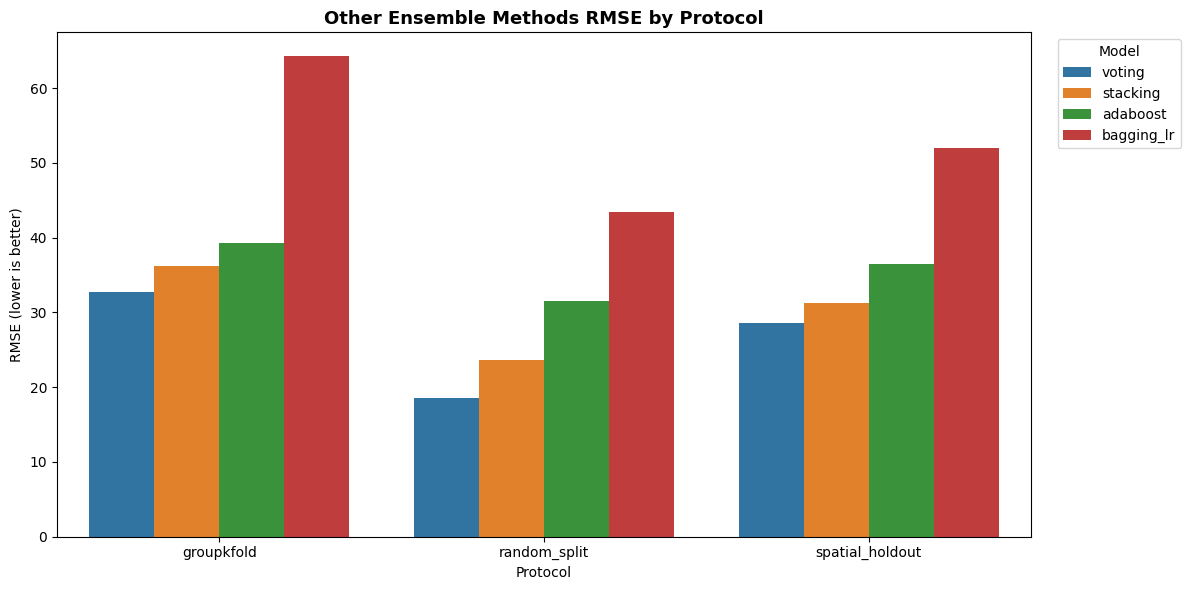

Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\11_other_ensemble_no_scripts\outputs\summary\figures\rmse_by_protocol_other_ensembles.png


In [12]:
plot_df = summary.copy()
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x='protocol', y='rmse', hue='model_name', ax=ax)
ax.set_title('Other Ensemble Methods RMSE by Protocol', fontsize=13, fontweight='bold')
ax.set_xlabel('Protocol')
ax.set_ylabel('RMSE (lower is better)')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

bar_path = SUMMARY_FIG_ROOT / 'rmse_by_protocol_other_ensembles.png'
fig.savefig(bar_path, dpi=600, bbox_inches='tight')
plt.show()
print('Saved:', bar_path)

### Checklist
1. Use `outputs/summary/tables/all_model_protocol_summary.csv` for cross-model comparison.
2. Compare these 4 models against NB09's best (gradient_boosting avg_rank=2.67, xgboost avg_rank=1.67) using the same RMSE scale.
3. `VotingRegressor` and `StackingRegressor` use the NB09/10 winning configs as base estimators â€” if they beat those winners, it validates multi-model combination.
4. `AdaBoostRegressor` will reveal whether adaptive weighting adds value over gradient-based boosting.
5. `BaggingRegressor` with LinearRegression tests whether bagging non-tree bases adds diversity to the ensemble pool.

In [13]:
# N6.1 — Nested CV for unbiased spatial RMSE estimate
# Outer CV: GroupKFold(5), Inner CV: KFold(3) — groups only needed at outer level
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, GridSearchCV, GroupKFold, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, mean_squared_error

_data_path = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/03_data_processed/geothermal_canonical_v2_0_0.csv')
_df = pd.read_csv(_data_path)
_TARGET = 'Temperature(C)'; _GROUP = 'State'
_X = _df.drop(columns=[_TARGET]); _y = _df[_TARGET]; _g = _df[_GROUP]

_num_cols = _X.select_dtypes(include=[np.number]).columns.tolist()
_cat_cols = [c for c in _X.columns if c not in _num_cols]
_prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), _num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]), _cat_cols),
])
_pipe = Pipeline([('prep', _prep),
                  ('reg', GradientBoostingRegressor(random_state=42))])

# Inner CV uses KFold (not GroupKFold) — groups parameter is not forwarded into GridSearchCV
_inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
_outer_cv = GroupKFold(n_splits=5)

_grid = GridSearchCV(
    _pipe,
    param_grid={'reg__n_estimators': [200, 350], 'reg__max_depth': [3, 4]},
    cv=_inner_cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

_neg_rmse = make_scorer(lambda y, p: -np.sqrt(mean_squared_error(y, p)))
_nested_scores = cross_val_score(
    _grid, _X, _y, groups=_g, cv=_outer_cv, scoring=_neg_rmse, n_jobs=1)

print("=== N6.1 Nested CV — unbiased spatial RMSE (outer GroupKFold-5) ===")
print(f"Nested CV RMSE: {-_nested_scores.mean():.2f} ± {_nested_scores.std():.2f}")
print(f"Per-fold RMSE: {[-round(s, 2) for s in _nested_scores]}")


=== N6.1 Nested CV — unbiased spatial RMSE (outer GroupKFold-5) ===
Nested CV RMSE: 32.86 ± 14.16
Per-fold RMSE: [np.float64(32.67), np.float64(36.99), np.float64(7.12), np.float64(37.23), np.float64(50.28)]


In [14]:
# X1.1 — ManualGroupStackingRegressor results (Paper 2 canonical)
# The main benchmark loops above now use ManualGroupStackingRegressor for the stacking model.
# Results are read directly from the summary table computed in the cell above.

print("=== X1.1 ManualGroupStackingRegressor — Paper 2 canonical results ===")
stacking_rows = summary[summary['model_name'] == 'stacking'].sort_values('protocol')
for _, row in stacking_rows.iterrows():
    print(f"  {row['protocol']:20s}: RMSE={row['rmse']:.2f}  R2={row['r2']:.3f}")
print("\nExpected: random_split=23.63, groupkfold=36.21, spatial_holdout=31.20")
print("\nManualGroupStackingRegressor uses cross_val_predict(cv=GroupKFold(5), groups=state)")
print("  so OOF meta-features are free of state leakage. Meta-learner: Ridge(alpha=1.0).")

=== X1.1 ManualGroupStackingRegressor — Paper 2 canonical results ===
  groupkfold          : RMSE=36.21  R2=-29.404
  random_split        : RMSE=23.63  R2=0.495
  spatial_holdout     : RMSE=31.21  R2=-29.274

Expected: random_split=23.63, groupkfold=36.21, spatial_holdout=31.20

ManualGroupStackingRegressor uses cross_val_predict(cv=GroupKFold(5), groups=state)
  so OOF meta-features are free of state leakage. Meta-learner: Ridge(alpha=1.0).


In [15]:
# N8.5 â€” Environment watermark for reproducibility
try:
    import watermark
    %load_ext watermark
    %watermark -v -p numpy,pandas,scikit-learn,scipy,matplotlib,xgboost
except ImportError:
    import sys, numpy, pandas, sklearn, scipy, matplotlib
    print(f"Python {sys.version}")
    print(f"numpy={numpy.__version__}, pandas={pandas.__version__}")
    print(f"scikit-learn={sklearn.__version__}, scipy={scipy.__version__}")
    print(f"matplotlib={matplotlib.__version__}")
    try:
        import xgboost; print(f"xgboost={xgboost.__version__}")
    except ImportError:
        pass

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.11.0

numpy       : 2.4.2
pandas      : 2.2.2
scikit-learn: 1.8.0
scipy       : 1.17.1
matplotlib  : 3.10.8
xgboost     : 3.2.0

